In [1]:
#%config InlineBackend.figure_formats=['svg']
# Generic import 
import numpy as np
from os import listdir
import matplotlib.pyplot as plt
# Train a model
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.utils.plot import load_run_results
# Define clustering
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture

from matplotlib.pyplot import cm

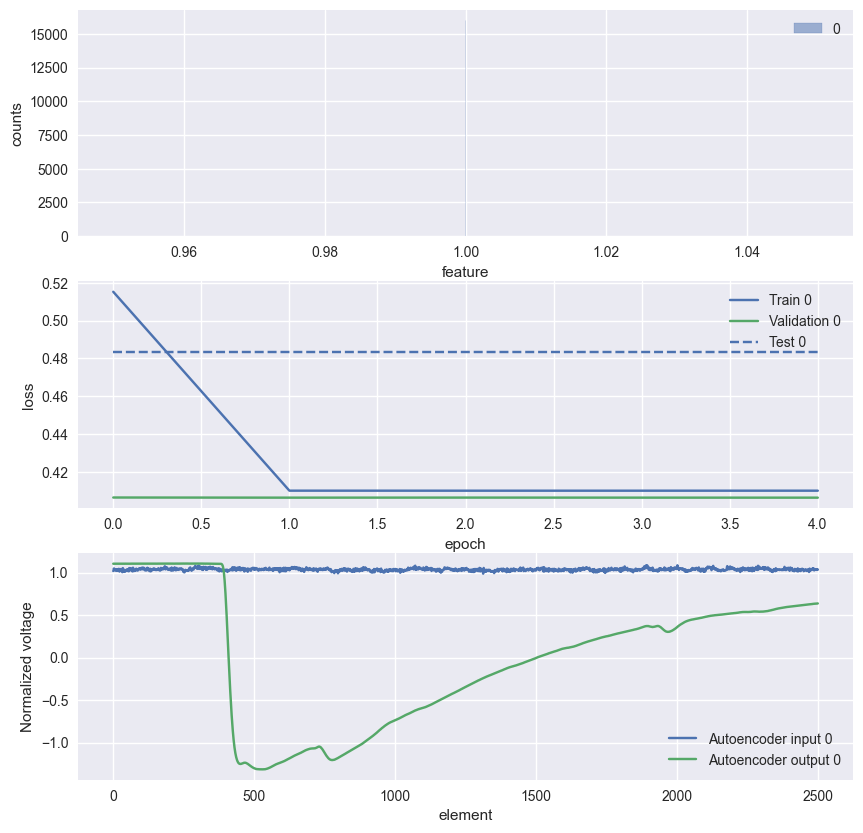

In [3]:
load_run_results("AutoencoderLog/sweep 2 layers/run 0/run-2023-12-16-11-28", bw=[0.008])

### Train a model

The first step is to choose an autoencoder architecture from the available options and optimize its hyperparameters.
The optimization can be done using the `sweep` method (futur document will be written on hyperparameter optimization).
The optimal architecture and parameters are case dependant but a simple architecture appears to be enough for most cases.

In [14]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST (250) train",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250, 
        },
'network' : {
        'activation_list'          : ['GELU', 'GELU', 'PReLU', 'GELU', 'GELU'],
        'layer_list'               : [200, 100, 50, 1, 50, 100, 200],
        'layer_number'             : 4,
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'TripletMSE', 
        'alpha'                    : 0.002,
        'epochs'                   : 6,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-6
        }
}

With the proper config dictionnary it is now possible to run an experiment and train our network.
A `run` folder with the date and time will be created in the specified path.

In [15]:
autoencoder = recurrentTriplet()
#autoencoder.run(run_config_Triplet)

It is possible to directly analyse our results through the `load_run_results` function.

In [16]:
#load_run_results("AutoencoderLog/run-2023-10-01-09-41", [0.01])

### Define clustering

If the autoencoder successfully accomplishes its intended task it is possible to fit our training data using a clustering method.
In this case th K-Means method is used since it is easily scalable.

First import the set on which the clustering is trained on.

In [17]:
signal_size = 250
path_test = r'C:\Users\dalbe\Documents\Datasets/TES/NIST (250) test/'
path_train = r'C:\Users\dalbe\Documents\Datasets/TES/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

In [18]:
signal_size = 30_000
path_test = r"C:\Users\dalbe\Documents\Datasets\SNSPD\Paderborn\data/"
#path_train = r'C:\Users\dalbe\Documents\Datasets/TES/NIST (250) train/'

X_test = np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

#X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
#X_train = X_train.astype("double")
X_train = X_test

In [ ]:
agm = autoencoder_gaussianMixture('AutoencoderLog/run-2023-12-16-09-54/fold 0')
#agm = autoencoder_gaussianMixture('AutoencoderLog/run-2023-11-24-15-47/fold 0')
#agm = autoencoder_gaussianMixture('Test/test NIST (250)/fold 0/')

Train the kernel density and gaussian mixture and define the interval of possible number of cluster

In [ ]:
agm.fit(np.copy(X_train),
        bins_plot=5000,
        plot_cluster=True,
        plot_traces=True,
        plot_traces_average=True,
        plot_cross_talk=True,
        bw_cst=[0.009],
        filter_input=False,
        filter_threshold = 0.0004,
        skip = 1,
        flip=False)

KeyboardInterrupt: 

In [ ]:
clusters_low_dim = agm.get_clusters(np.copy(X_test),
                                    filter_input = True,
                                    filter_threshold = 0.0005)

IndexError: The shape of the mask [57033] at index 0 does not match the shape of the indexed tensor [14258250] at index 0

In [ ]:
def gaussian_function(x, mean, variance):
    return (2*np.pi*variance)**(-1/2) * np.exp(-(x - mean)**2/(2*variance))

min_ = -0.6
max_ = 1
bins = np.linspace(min_, max_, 5000)

x = np.linspace(min_, max_, 1000).reshape(-1,1)
n =len(clusters_low_dim)
color = iter(cm.GnBu_r(np.linspace(0, 1, int(1.5*n))))

#with plt.rc_context({'axes.edgecolor':'white', 'xtick.color':'white', 'ytick.color':'white', 'figure.facecolor':'white'}):
with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(10,4)) #, dpi=100
    for index_cluster, cluster in enumerate(clusters_low_dim):
        c = next(color)
        plt.hist(cluster , bins, label=f"{index_cluster}", fill=True, histtype='step',color=c)#"#8dd3c7")
    for index, mean_value in enumerate(agm.cluster_means):
        plt.plot(x, gaussian_function(x, mean_value, agm.cluster_covariance[index]), color="k")
    plt.xlabel("Latent Space")
    plt.ylabel("Counts")

    plt.legend(ncol=3)
    plt.show()

NameError: name 'clusters_low_dim' is not defined

### From traces to labels

The `autoencoder_object` is now trained and initialized, it is possible to get the label of new traces by using the `get_label` function.

In [ ]:
from timeit import default_timer as timer

In [ ]:
X = X_test
start = timer()
lab = agm.get_label_filter(X)
end = timer()

print("Number of traces : ", len(X))
print("Number of traces per second : ",int(len(X) / (end - start)))

Number of traces :  71680
Number of traces per second :  419507


tensor([[[14]],

        [[17]],

        [[14]],

        ...,

        [[ 1]],

        [[ 1]],

        [[ 2]]])

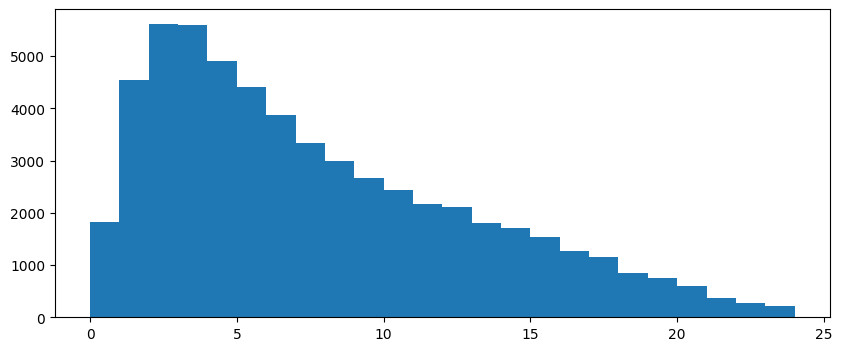

In [ ]:
plt.figure(figsize=(10,4), dpi=100)
plt.hist(lab.view(-1), bins=24)
plt.show()

In [ ]:
from sklearn.manifold import TSNE
from ExistingAlgorithms.SklearnAvailable import dimension_reduction
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture


#X_i_TSNE, X_r_TSNE, X_l_TSNE = dimension_reduction(np.copy(X_train),np.copy(X_test),TSNE,n_components=1, perplexity=250)

In [ ]:
path_test = r'C:\Users\dalbe\Documents\Datasets\SNSPD\Paderborn\data'
files = ['TracesNr1.npy']

X_SNSPD = np.concatenate([np.load(f"{path_test}\{fileName}").reshape(-1,30000) for fileName in files])
X_SNSPD = -1 * X_SNSPD.astype("double")
np.shape(X_SNSPD)

(1000, 30000)

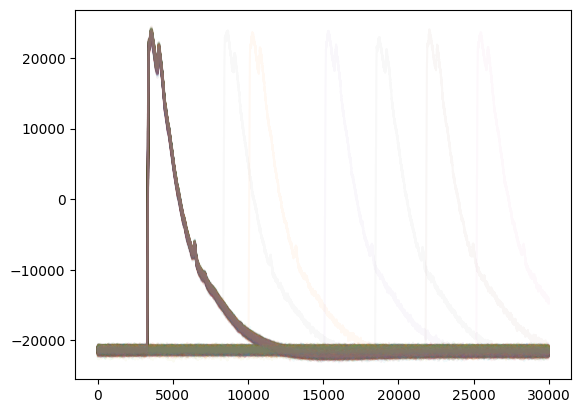

In [ ]:
p = [plt.plot(i, alpha=0.05) for i in X_SNSPD]
plt.show();

In [ ]:
path_test = r'C:\Users\dalbe\Documents\Datasets\SNSPD\Paderborn'

db = np.load(f"{path_test}\db_shuffled.npy")
n = np.load(f"{path_test}\dB.npy")
#plt.plot(n)
n

array([18.97, 15.99, 14.24, 13.  , 12.04, 11.25, 10.59, 10.01,  9.5 ,
        9.05, 18.97])

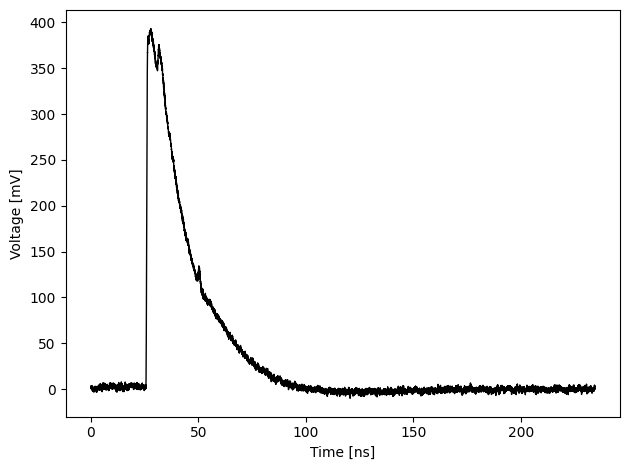

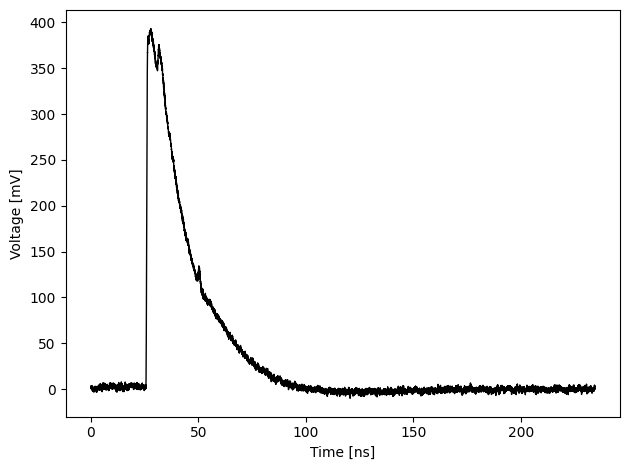

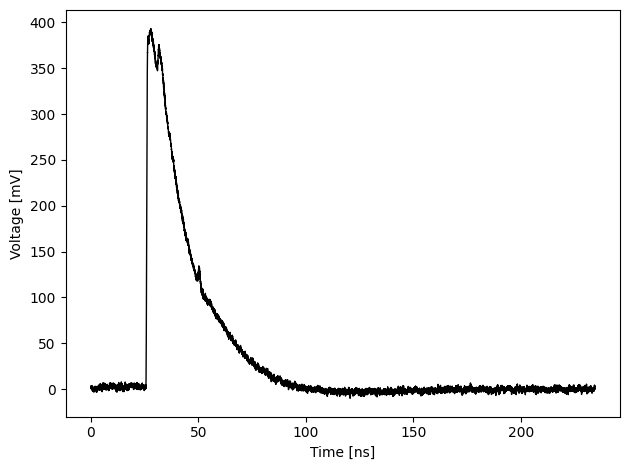

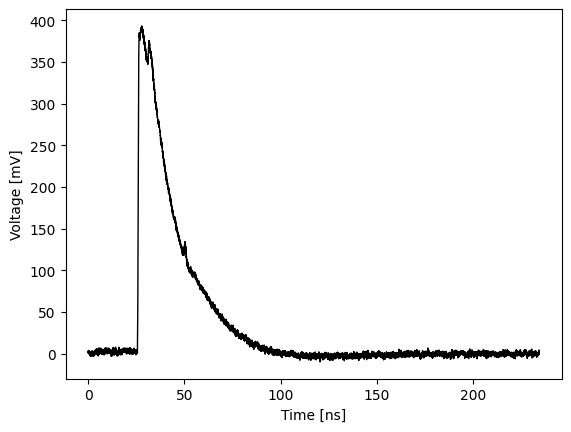

In [ ]:
x_inc = 0.78125e-2 #x axis (time) scaling factor
y_inc = 8.633e-3 #y axis (voltage) scaling factor
x_0 = 0 #x axis offset
y_0 = -1.84924e2*-1 #y axis offset

i = 0 #index of the trace to plot
n = 1000 #number of traces per file
l = 30000 #length of on trace

voltage = np.load(f"{path_test}\{files[0]}")[i*l:i*l+l] * -1 #multiply by -1 to flip the trace 
time = np.arange(l)*x_inc + x_0 #time axis

plt.figure()
plt.plot(time, voltage*y_inc + y_0, color='black', linewidth=1)
plt.ylabel('Voltage [mV]')
plt.xlabel('Time [ns]')
plt.show()